In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import matplotlib.pyplot as plt
import torch
import numpy as np
from torchvision.utils import make_grid
from tqdm import tqdm
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.67MB/s]


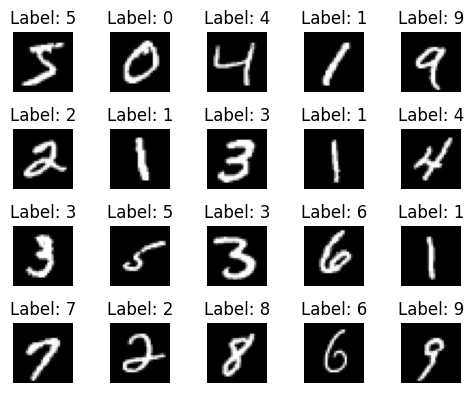

In [ ]:
transform = transforms.ToTensor()
trainset = torchvision.datasets.MNIST("./data", train=True, transform=transform, download=True)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

def show_images(dataset, num_samples=20, cols=4):
    plt.figure(figsize=(5, 5))
    for i, (img, label) in enumerate(dataset):
        if i == num_samples:
            break
        plt.subplot(int(num_samples/cols) + 1, cols, i + 1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_images(trainset, num_samples=20, cols=5)


# VAE

In [ ]:
latent_dim = 1

In [ ]:
class Encoder(nn.Module):
  def __init__(self, latent_dim):
    super().__init__()

    self.encoderBlock = nn.Sequential(
        nn.Conv2d(1, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.SiLU(),
        nn.Conv2d(64, 64, kernel_size=2, stride=2),
        nn.BatchNorm2d(64),
        nn.SiLU(),
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.SiLU(),
        nn.Conv2d(128, 128, kernel_size=2, stride=2),
        nn.BatchNorm2d(128),
        nn.SiLU(),
        nn.Flatten()
    )

    self.mu = nn.Linear(128 * 7 * 7, latent_dim)
    self.logvar = nn.Linear(128 * 7 * 7, latent_dim)

  def forward(self, X):
    encoderOut = self.encoderBlock(X)
    return self.mu(encoderOut), self.logvar(encoderOut)

class Decoder(nn.Module):
  def __init__(self, latent_dim):
    super().__init__()
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, 64 * 7 * 7),
        nn.SiLU(),
        nn.Unflatten(1, (64, 7, 7)),
        nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2),
        nn.BatchNorm2d(64),
        nn.SiLU(),
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.SiLU(),
        nn.ConvTranspose2d(128, 128, kernel_size=2, stride=2),
        nn.BatchNorm2d(128),
        nn.SiLU(),
        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.SiLU(),
        nn.Conv2d(256, 1, kernel_size=3, padding=1),
        nn.Tanh()
    )

  def forward(self, z):
    return self.decoder(z)

In [ ]:
class VAE(nn.Module):
  def __init__(self, latent_dim):
    super().__init__()
    self.encoder = Encoder(latent_dim)
    self.decoder = Decoder(latent_dim)

  def forward(self, X):
    mu, logvar = self.encoder(X)
    sigma = torch.exp(0.5 * logvar)
    eps = torch.randn_like(logvar)
    z = mu + sigma * eps # Reparameterisation
    return self.decoder(z), mu, logvar

In [ ]:
lr = 1e-4

model = VAE(latent_dim).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr)

reconstructionLoss = nn.MSELoss()


KL Divergence loss equation
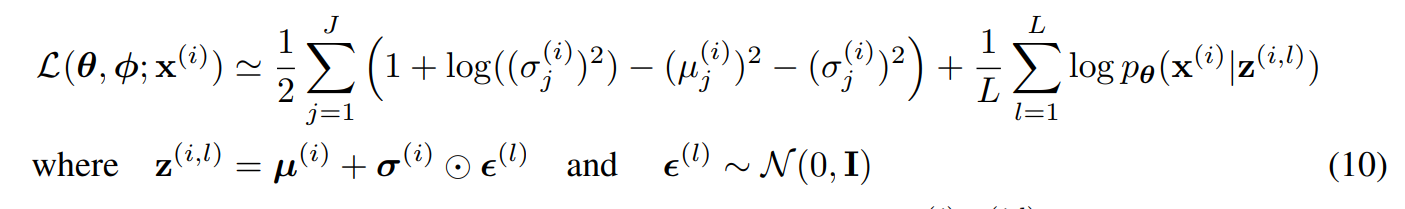

In [ ]:
for epoch in range(20):
  lossSum = 0
  for idx, (X, y) in enumerate(tqdm(trainloader)):
    X = X.to(device)
    reconstructed, mu, logvar = model(X)

    optimizer.zero_grad()
    """
    if torch.isnan(mu).any():
      print(f"NaN in mu at batch {idx}")
    if torch.isnan(logvar).any():
      print(f"NaN in logvar at batch {idx}")
    if torch.isnan(reconstructed).any():
      print(f"NaN in reconstructed at batch {idx}")
    """
    rLoss = reconstructionLoss(reconstructed, X)
    kldLoss = -0.5 * torch.sum((1 + logvar - mu ** 2 - logvar.exp()))

    loss = rLoss + kldLoss * 7e-5
    lossSum += loss.item()

    loss.backward()
    optimizer.step()
  print(f"Epoch {epoch}: Loss = {lossSum / len(trainloader)}")


100%|██████████| 938/938 [00:29<00:00, 32.11it/s]


Epoch 0: Loss = 0.06315622507715657


100%|██████████| 938/938 [00:29<00:00, 32.31it/s]


Epoch 1: Loss = 0.06300292771730596


100%|██████████| 938/938 [00:28<00:00, 33.14it/s]


...

Epoch 17: Loss = 0.062285489380868


100%|██████████| 938/938 [00:28<00:00, 32.94it/s]


Epoch 18: Loss = 0.06226685998647579


100%|██████████| 938/938 [00:28<00:00, 32.93it/s]

Epoch 19: Loss = 0.062272589475011776


In [ ]:
#torch.save(model.state_dict(), "/content/gdrive/My Drive/Colab Notebooks/Learning/mnistVAEmodelWeights")

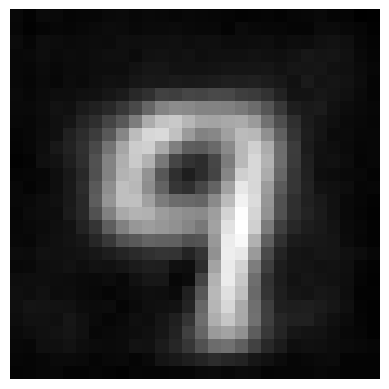

In [ ]:
#z = torch.randn(1, latent_dim, device=device)
z = torch.randn(1, latent_dim, device=device)

plt.imshow(model.decoder(z).detach().cpu()[0, 0], cmap='gray')
plt.axis("off")
plt.show()

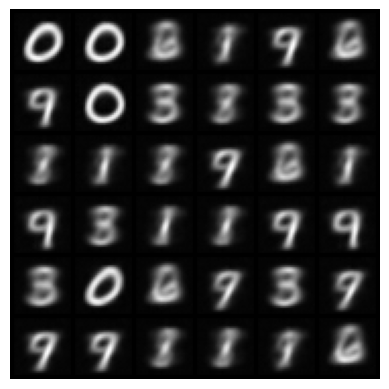

In [ ]:
z = torch.randn(36, latent_dim, device=device)
generated = model.decoder(z).detach().cpu()
grid = torchvision.utils.make_grid(generated, nrow=6, normalize=True)
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis("off")
plt.show()